## Problem 1: Block Matching and 3D Filtering:

In [1]:
import sys
import os

In [2]:
sys.path.append(os.path.abspath('./bm3d-4.0.3'))

In [3]:
!pip install bm4d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.0/862.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 16.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [bm4d]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np
import bm3d
import matplotlib.pyplot as plt
import skimage
from skimage.metrics import mean_squared_error

### 1. Comparing MSE Performance

In [19]:
clean_img = skimage.img_as_float(skimage.io.imread('./dataset/cameramanclean.png', as_gray=True))
noisy_img = skimage.img_as_float(skimage.io.imread('./dataset/cameramannoisy.png', as_gray=True))

In [25]:
assumed_std = 0.25
print(f"Assumed Noise Variance: {np.square(assumed_std)}")

# 1st Stage: only hard thresholding
denoised_stage1 = bm3d.bm3d(noisy_img, sigma_psd=assumed_std, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)
mse_stage1 = mean_squared_error(clean_img, denoised_stage1)

# 2nd Stage: hard thresholding + Wiener filtering
denoised_stage2 = bm3d.bm3d(noisy_img, sigma_psd=assumed_std, stage_arg=bm3d.BM3DStages.ALL_STAGES)
mse_stage2 = mean_squared_error(clean_img, denoised_stage2)

print(f"MSE after 1st stage: {mse_stage1:.6f}")
print(f"MSE after 1st and 2nd stage: {mse_stage2:.6f}")

Assumed Noise Variance: 0.0625
MSE after 1st stage: 0.012854
MSE after 1st and 2nd stage: 0.009960


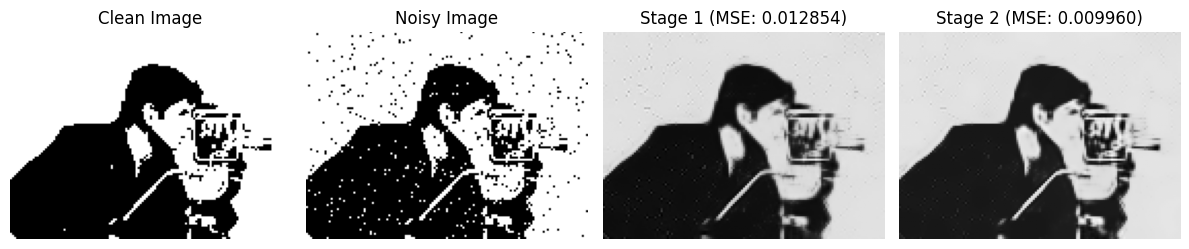

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
axes[0].imshow(clean_img, cmap='gray')
axes[0].set_title("Clean Image")
axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title("Noisy Image")
axes[2].imshow(denoised_stage1, cmap='gray')
axes[2].set_title(f"Stage 1 (MSE: {mse_stage1:.6f})")
axes[3].imshow(denoised_stage2, cmap='gray')
axes[3].set_title(f"Stage 2 (MSE: {mse_stage2:.6f})")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 2. MSE vs Noise Variance

In [20]:
true_variance = mean_squared_error(clean_img, noisy_img)
true_std = np.sqrt(true_variance)
print(f"True Variance of the noise: {true_variance:.6f}")

True Variance of the noise: 0.025800


/Users/bitupan_arandhara/Desktop/Study/IISc/AIP/aip_env/lib/python3.10/site-packages/bm4d/__init__.py:615: RuntimeWarning: divide by zero encountered in matmul
  t_forward = (t_forward.T @ np.diag(np.sqrt(1. / sum(t_forward ** 2, 0)))).T
/Users/bitupan_arandhara/Desktop/Study/IISc/AIP/aip_env/lib/python3.10/site-packages/bm4d/__init__.py:615: RuntimeWarning: overflow encountered in matmul
  t_forward = (t_forward.T @ np.diag(np.sqrt(1. / sum(t_forward ** 2, 0)))).T
/Users/bitupan_arandhara/Desktop/Study/IISc/AIP/aip_env/lib/python3.10/site-packages/bm4d/__init__.py:615: RuntimeWarning: invalid value encountered in matmul
  t_forward = (t_forward.T @ np.diag(np.sqrt(1. / sum(t_forward ** 2, 0)))).T


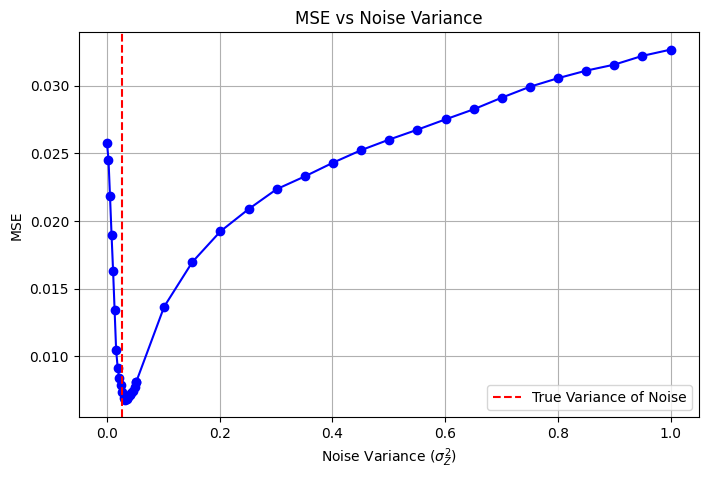

In [21]:
sigma_sq_list = np.linspace(0, true_variance * 2, 20)
sigma_sq_list = np.concatenate((sigma_sq_list, np.linspace(true_variance * 2, 1, 20)))
mse_values = []

for sigma_sq in sigma_sq_list:
    sigma = np.sqrt(sigma_sq)
    denoised_img = bm3d.bm3d(noisy_img, sigma_psd=sigma, stage_arg=bm3d.BM3DStages.ALL_STAGES)
    mse = mean_squared_error(clean_img, denoised_img)
    mse_values.append(mse)

plt.figure(figsize=(8, 5))
plt.plot(sigma_sq_list, mse_values, marker='o', linestyle='-', color='b')
plt.axvline(true_variance, color='r', linestyle='--', label='True Variance of Noise')
plt.xlabel("Noise Variance ($\sigma_Z^2$)")
plt.ylabel("MSE")
plt.title("MSE vs Noise Variance")
plt.legend()
plt.grid(True)
plt.show()

### Replacing Wiener Filter with Hard Thresholding

In [27]:
# get pilot image from Stage 1
denoised_stage1 = bm3d.bm3d(noisy_img, sigma_psd=assumed_std, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)
# get the block match coords
_, matches_from_pilot = bm3d.bm3d(denoised_stage1, sigma_psd=0, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING, blockmatches=(True, False))
# apply hard thresholding using the block matches
denoised_stage2_ht = bm3d.bm3d(noisy_img, sigma_psd=assumed_std, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING, blockmatches=matches_from_pilot)

mse_stage2_ht = mean_squared_error(clean_img, denoised_stage2_ht)
print(f"MSE after Stage 2 (Wiener Filtering) : {mse_stage2:.6f}")
print(f"MSE after Stage 2 (Hard Thresholding) : {mse_stage2_ht:.6f}")

MSE after Stage 2 (Wiener Filtering) : 0.009960
MSE after Stage 2 (Hard Thresholding) : 0.012855
